# Análisis de ventas - Online Retail

Este proyecto tiene como objetivo analizar el comportamiento de las ventas a partir del conjunto de datos Online Retail. Se analizarán aspectos relacionados con el comportamiento de compra, los ingresos, el desempeño de los productos, la demanda y las diferencias entre mercados.

Como parte del proceso, primero se realizó una exploración de los datos para conocer su estructura, identificar posibles problemas de calidad y analizar registros que requerían un tratamiento específico. A partir de esta exploración se definió un proceso de limpieza y transformación mediante un script independiente (clean_data.py), cuyo resultado se utiliza como base para los análisis posteriores.



## Carga y verificación del dataset limpio


In [1]:
# Cargamos el dataset limpio generado por el script
import pandas as pd
data_clean = pd.read_csv('../data/processed/data_clean.csv')

In [2]:
# Revisamos las dimensiones y las variables disponibles en data_clean
print(data_clean.shape)
print(data_clean.columns.tolist())

(539434, 10)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Mes', 'Revenue']


# 1. Pregunta de investigación 1
Si un cliente compra el producto X, ¿cuál es la probabilidad de que compre también el producto Y?

In [3]:
# Comprobamos las dimensiones del dataset limpio
data_clean.shape

(539434, 10)

In [4]:
# Revisamos algunas variables relevantes para el análisis de asociación
data_clean[['InvoiceNo', 'CustomerID', 'StockCode', 'Quantity']].head()

,InvoiceNo,CustomerID,StockCode,Quantity
0,536365,17850.0,85123A,6
1,536365,17850.0,71053,6
2,536365,17850.0,84406B,8
3,536365,17850.0,84029G,6
4,536365,17850.0,84029E,6


In [5]:
# Conservamos las compras con cantidades positivas
compras = data_clean[data_clean['Quantity'] > 0]

In [6]:
# Identificamos los productos que aparecen en cada factura
productos_por_factura = compras.groupby('InvoiceNo')['StockCode'].unique()

In [7]:
# Importamos herramientas para generar y contar pares de productos
from itertools import combinations
from collections import Counter

In [8]:
# Contamos las combinaciones de dos productos que aparecen en una misma factura
contador_pares = Counter()

for productos in productos_por_factura.values:
    contador_pares.update(combinations(productos, 2))

In [9]:
# Calculamos en cuántas facturas aparece cada producto
facturas_por_producto = compras.groupby('StockCode')['InvoiceNo'].nunique()

In [10]:
# Revisamos las 10 combinaciones de productos más frecuentes
contador_pares.most_common(10)

[(('22386', '85099B'), 523),
 (('22697', '22699'), 477),
 (('85099B', 'DOT'), 460),
 (('22411', '85099B'), 458),
 (('21931', '85099B'), 444),
 (('20725', '20727'), 408),
 (('22697', '22698'), 391),
 (('85099B', '85099C'), 382),
 (('23199', '85099B'), 378),
 (('20719', '20724'), 373)]

In [11]:
# Creamos una lista para almacenar los resultados del análisis
resultados = []

In [12]:
# Preparamos nuevamente las facturas por producto como diccionario
facturas_por_producto = compras.groupby('StockCode')['InvoiceNo'].nunique().to_dict()

In [13]:
# Calculamos la probabilidad de comprar un producto dado que se compró el otro
for pareja, frecuencia in contador_pares.items():
    if frecuencia >= 10:
        producto_x, producto_y = pareja
        
        facturas_x = facturas_por_producto[producto_x]
        probabilidad = frecuencia / facturas_x
        
        resultados.append([
            producto_x,
            producto_y,
            frecuencia,
            facturas_x,
            probabilidad
        ])

In [14]:
# Convertimos los resultados en un DataFrame
resultados_df = pd.DataFrame(
    resultados,
    columns=[
        'Producto_X',
        'Producto_Y',
        'Frecuencia',
        'Facturas_X',
        'Probabilidad'
    ]
)

In [15]:
# Verificamos la cantidad de resultados obtenidos
resultados_df.shape

(743595, 5)

In [16]:
# Ordenamos los pares de productos de mayor a menor probabilidad
resultados_df = resultados_df.sort_values(
    'Probabilidad',
    ascending=False
)

In [17]:
# Conservamos los pares que aparecen al menos 50 veces
resultados_top = resultados_df[
    resultados_df['Frecuencia'] >= 50
].copy()

### Descripción de los productos

In [18]:
data_clean[['StockCode', 'Description']].head()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.


In [19]:
# Creamos una tabla con una descripción por cada StockCode

descripciones = compras[['StockCode', 'Description']].dropna(subset=['Description'])

descripciones = descripciones.drop_duplicates('StockCode')

In [20]:
# Comprobamos las descripciones obtenidas
descripciones.head()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.


In [21]:
# Creamos un diccionario para buscar rápidamente la descripción de cada producto
diccionario_descripciones = dict(
    zip(descripciones['StockCode'], descripciones['Description'])
)

In [22]:
# Agregamos la descripción del Producto X
resultados_top['Descripcion_X'] = resultados_top['Producto_X'].map(
    diccionario_descripciones
)

In [23]:
# Agregamos la descripción del Producto Y
resultados_top['Descripcion_Y'] = resultados_top['Producto_Y'].map(
    diccionario_descripciones
)

In [24]:
# Revisamos los pares de productos con sus descripciones
resultados_top.head(10)

,Producto_X,Producto_Y,Frecuencia,Facturas_X,Probabilidad,Descripcion_X,Descripcion_Y
485703,84997a,DOT,65,65,1.000000,GREEN 3 PIECE POLKADOT CUTLERY SET,DOTCOM POSTAGE
491462,84509a,DOT,68,68,1.000000,SET OF 4 ENGLISH ROSE PLACEMATS,DOTCOM POSTAGE
140366,84970s,DOT,64,66,0.969697,HANGING HEART ZINC T-LIGHT HOLDER,DOTCOM POSTAGE
140348,47566b,DOT,96,102,0.941176,TEA TIME PARTY BUNTING,DOTCOM POSTAGE
140354,72349b,DOT,77,82,0.939024,SET/6 PURPLE BUTTERFLY T-LIGHTS,DOTCOM POSTAGE
130807,84923,DOT,91,98,0.928571,PINK BUTTERFLY HANDBAG W BOBBLES,DOTCOM POSTAGE
485071,85123a,DOT,60,67,0.895522,WHITE HANGING HEART T-LIGHT HOLDER,DOTCOM POSTAGE
63075,85131B,DOT,154,172,0.895349,BEADED CRYSTAL HEART GREEN ON STICK,DOTCOM POSTAGE
131249,85131D,DOT,184,206,0.893204,BEADED CRYSTAL HEART PINK ON STICK,DOTCOM POSTAGE
186343,84997c,84997d,55,62,0.887097,BLUE 3 PIECE POLKADOT CUTLERY SET,PINK 3 PIECE POLKADOT CUTLERY SET


**Tratamiento de DOTCOM POSTAGE**

DOT corresponde a DOTCOM POSTAGE, un cargo asociado al envío. Aunque estos registros generan ingresos, no representan la compra de un producto físico, por lo que se excluyen del análisis de asociación entre productos.

In [25]:
# Excluimos DOTCOM POSTAGE porque corresponde a un cargo de envío y no a un producto físico
resultados_productos = resultados_top[
    (resultados_top['Producto_X'] != 'DOT') &
    (resultados_top['Producto_Y'] != 'DOT')
].copy()

In [26]:
# Verificamos la cantidad de pares restantes
resultados_productos.shape

(27019, 7)

In [27]:
# Revisamos los pares de productos con mayor probabilidad
resultados_productos.head(10)

,Producto_X,Producto_Y,Frecuencia,Facturas_X,Probabilidad,Descripcion_X,Descripcion_Y
186343,84997c,84997d,55,62,0.887097,BLUE 3 PIECE POLKADOT CUTLERY SET,PINK 3 PIECE POLKADOT CUTLERY SET
485700,84997a,85099B,57,65,0.876923,GREEN 3 PIECE POLKADOT CUTLERY SET,JUMBO BAG RED RETROSPOT
186340,84997b,84997d,58,67,0.865672,RED 3 PIECE RETROSPOT CUTLERY SET,PINK 3 PIECE POLKADOT CUTLERY SET
140365,84970s,85099B,56,66,0.848485,HANGING HEART ZINC T-LIGHT HOLDER,JUMBO BAG RED RETROSPOT
491460,84509a,85099B,57,68,0.838235,SET OF 4 ENGLISH ROSE PLACEMATS,JUMBO BAG RED RETROSPOT
186280,82494l,85099C,51,61,0.836066,WOODEN FRAME ANTIQUE WHITE,JUMBO BAG BAROQUE BLACK WHITE
140353,72349b,85099B,65,82,0.792683,SET/6 PURPLE BUTTERFLY T-LIGHTS,JUMBO BAG RED RETROSPOT
186339,84997b,84997c,52,67,0.776119,RED 3 PIECE RETROSPOT CUTLERY SET,BLUE 3 PIECE POLKADOT CUTLERY SET
140347,47566b,85099B,79,102,0.774510,TEA TIME PARTY BUNTING,JUMBO BAG RED RETROSPOT
131213,85131B,85131D,132,172,0.767442,BEADED CRYSTAL HEART GREEN ON STICK,BEADED CRYSTAL HEART PINK ON STICK


In [28]:
# Sacamos los 20 pares de mayor probabilidad para luego graficar
top_pares = resultados_productos.sort_values(
    'Probabilidad',
    ascending=False
).head(20)

top_pares

,Producto_X,Producto_Y,Frecuencia,Facturas_X,Probabilidad,Descripcion_X,Descripcion_Y
186343,84997c,84997d,55,62,0.887097,BLUE 3 PIECE POLKADOT CUTLERY SET,PINK 3 PIECE POLKADOT CUTLERY SET
485700,84997a,85099B,57,65,0.876923,GREEN 3 PIECE POLKADOT CUTLERY SET,JUMBO BAG RED RETROSPOT
186340,84997b,84997d,58,67,0.865672,RED 3 PIECE RETROSPOT CUTLERY SET,PINK 3 PIECE POLKADOT CUTLERY SET
140365,84970s,85099B,56,66,0.848485,HANGING HEART ZINC T-LIGHT HOLDER,JUMBO BAG RED RETROSPOT
491460,84509a,85099B,57,68,0.838235,SET OF 4 ENGLISH ROSE PLACEMATS,JUMBO BAG RED RETROSPOT
186280,82494l,85099C,51,61,0.836066,WOODEN FRAME ANTIQUE WHITE,JUMBO BAG BAROQUE BLACK WHITE
140353,72349b,85099B,65,82,0.792683,SET/6 PURPLE BUTTERFLY T-LIGHTS,JUMBO BAG RED RETROSPOT
186339,84997b,84997c,52,67,0.776119,RED 3 PIECE RETROSPOT CUTLERY SET,BLUE 3 PIECE POLKADOT CUTLERY SET
140347,47566b,85099B,79,102,0.774510,TEA TIME PARTY BUNTING,JUMBO BAG RED RETROSPOT
131213,85131B,85131D,132,172,0.767442,BEADED CRYSTAL HEART GREEN ON STICK,BEADED CRYSTAL HEART PINK ON STICK


In [29]:
q1_powerbi = resultados_productos[
    [
        'Producto_X',
        'Producto_Y',
        'Frecuencia',
        'Probabilidad',
        'Descripcion_X',
        'Descripcion_Y'
    ]
].copy()

q1_powerbi.to_csv(
    "../data/processed/q1_product_pairs.csv",
    index=False
)

print("Archivo Q1 creado correctamente.")

Archivo Q1 creado correctamente.


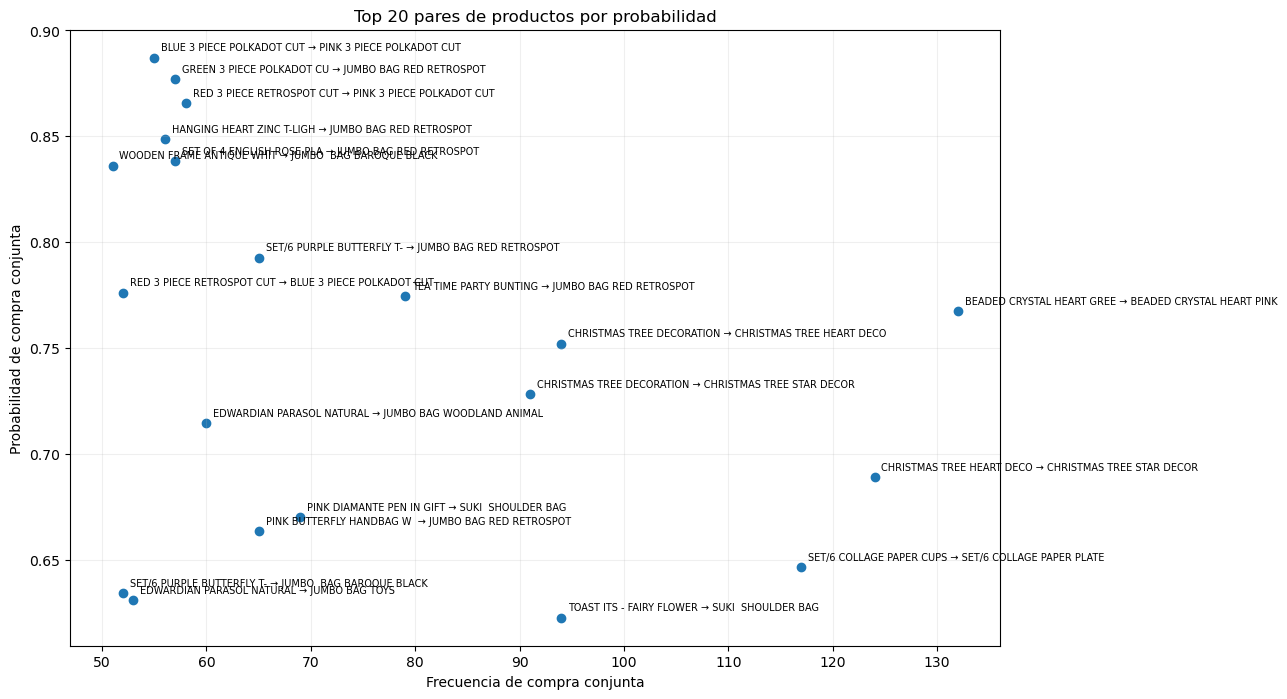

In [30]:
## Agregamos las descripciones al gráfico 

import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 8))

plt.scatter(
    top_pares['Frecuencia'],
    top_pares['Probabilidad']
)

for _, fila in top_pares.iterrows():
    etiqueta = f"{fila['Descripcion_X'][:25]} → {fila['Descripcion_Y'][:25]}"
    
    plt.annotate(
        etiqueta,
        (fila['Frecuencia'], fila['Probabilidad']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Frecuencia de compra conjunta')
plt.ylabel('Probabilidad de compra conjunta')
plt.title('Top 20 pares de productos por probabilidad')
plt.grid(alpha=0.2)

plt.show()


### Conclusión del análisis 
El análisis permitió identificar fuertes relaciones entre algunos pares de productos que suelen ser comprados conjuntamente. Los resultados muestran pares con probabilidades de compra conjunta superiores al 80%, algunos de ellos con una frecuencia considerable dentro del conjunto de datos. Estos patrones pueden ser aprovechados por la empresa para desarrollar estrategias de marketing, como recomendaciones de productos, promociones combinadas, ventas cruzadas (cross-selling) y creación de paquetes.

# 2. Pregunta de investigación 2
¿Cuáles son los meses con mayor generación de ingresos?

In [31]:
# Calculamos los ingresos totales por mes
ingresos_mensuales = (
    data_clean
    .groupby('Mes')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

ingresos_mensuales

Mes
2011-11    1461756.250
2011-10    1070704.670
2011-09    1019687.622
2010-12     748957.020
2011-05     723333.510
2011-06     691123.120
2011-03     683267.080
2011-08     682680.510
2011-07     681300.111
2011-01     560000.260
2011-02     498062.650
2011-04     493207.121
2011-12     433668.010
Name: Revenue, dtype: float64

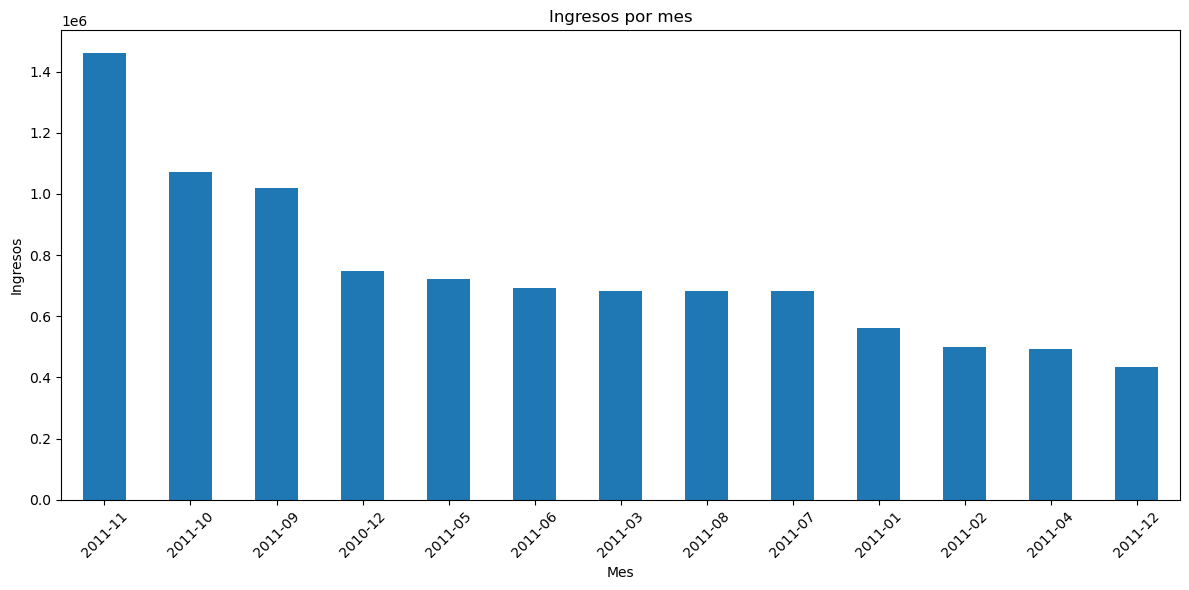

In [32]:
import matplotlib.pyplot as plt

# Gráfico de ingresos mensuales
ingresos_mensuales.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Ingresos por mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusión de la pregunta 2 

Los ingresos presentan diferencias importantes entre los distintos meses analizados. Noviembre de 2011 fue el período con mayores ingresos, seguido por octubre y septiembre de 2011, mientras que diciembre de 2011 presentó el nivel más bajo. Estos resultados muestran que el desempeño de las ventas varía significativamente a lo largo del año, lo que puede ser útil para identificar períodos de mayor actividad comercial y apoyar la planificación de estrategias de ventas, inventario y marketing.

Desde una perspectiva empresarial, identificar los meses de mayor y menor generación de ingresos permite anticipar períodos de alta demanda, planificar recursos y evaluar estrategias comerciales específicas para cada período.

# 3. PREGUNTA DE INVESTIGACIÓN 3
¿Qué productos generan mayores ingresos?


In [33]:
# Calculamos los ingresos totales por producto
ingresos_producto = data_clean.groupby('StockCode')['Revenue'].sum()

**Tratamiento de cargos de envío**

Los códigos DOT (DOTCOM POSTAGE) y POST (POSTAGE) corresponden a cargos asociados al envío y no a productos físicos. Aunque estos registros generan ingresos, se excluyen del ranking para identificar los productos que generan mayores ingresos por ventas.

In [34]:
# Excluimos los códigos correspondientes a cargos de envío
ingresos_productos_filtrados = ingresos_producto.drop(['DOT', 'POST'])

In [35]:
# Seleccionamos los 10 productos con mayores ingresos
ingresos_top = ingresos_productos_filtrados.nlargest(10)

In [36]:
# Revisamos los productos con mayores ingresos
ingresos_top

StockCode
22423     164762.19
47566      98302.98
85123A     97894.50
85099B     92356.03
23084      66756.59
22086      63791.94
84879      58959.73
79321      53768.06
22502      51041.37
22197      50987.47
Name: Revenue, dtype: float64

In [37]:
# Convertimos el índice en una columna
ingresos_top = ingresos_top.reset_index()

In [38]:
# Creamos una tabla con la descripción de cada producto
descripcion_productos = data_clean[
    ['StockCode', 'Description']
].drop_duplicates('StockCode')

In [39]:
# Unimos los ingresos con la descripción de cada producto
ingresos_top = ingresos_top.merge(
    descripcion_productos,
    on='StockCode',
    how='left'
)

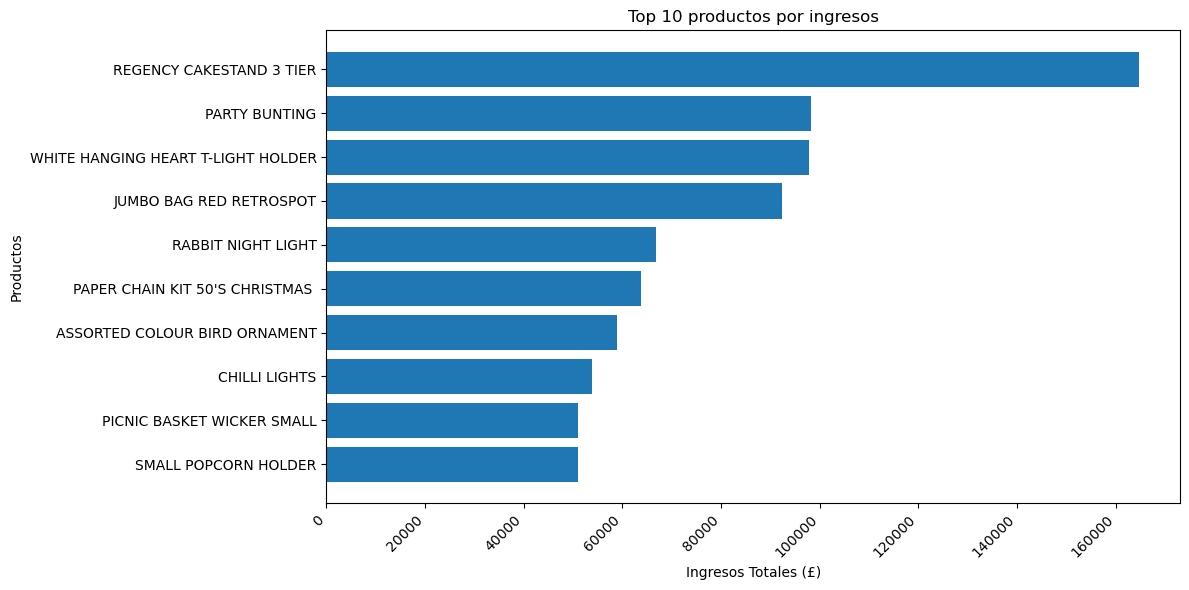

In [40]:
## Graficamos

plt.figure(figsize=(12, 6))

plt.barh(
    ingresos_top['Description'],
    ingresos_top['Revenue']
)

plt.xlabel('Ingresos Totales (£)')
plt.ylabel('Productos')
plt.title('Top 10 productos por ingresos')

plt.gca().invert_yaxis()

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Conclusión

Entre los productos analizados, el REGENCY CAKESTAND 3 TIER registra el mayor ingreso, con una diferencia notable respecto a los demás productos del Top 10. Le siguen PARTY BUNTING, WHITE HANGING HEART T-LIGHT HOLDER y JUMBO BAG RED RETROSPOT. Estos resultados permiten identificar los productos con mayor aporte a los ingresos por ventas y pueden servir como referencia para decisiones de inventario, promoción y comercialización.

# 4. PREGUNTA DE INVESTIGACIÓN 4 
¿Qué productos tienen alta rotación pero un bajo aporte relativo a los ingresos?

In [41]:
# Exploramos la cantidad vendida por código de producto
productos_mas_vendidos = data_clean.groupby('StockCode')['Quantity'].sum()

In [42]:
productos_mas_vendidos

StockCode
10002           860
10080           303
10120           193
10123C            5
10124A           16
               ... 
gift_0001_20     10
gift_0001_30      7
gift_0001_40      3
gift_0001_50      4
m                 1
Name: Quantity, Length: 3938, dtype: int64

**Preparación de los datos para el análisis de rotación**

Para analizar las unidades realmente vendidas de productos regulares, se excluyen los cargos de envío (DOT y POST), los vales de regalo (gift_), las operaciones manuales (M y m), las muestras (S) y PADS, debido a su comportamiento particular dentro del dataset. Además, se consideran únicamente cantidades positivas, ya que las cantidades negativas corresponden a devoluciones o ajustes.

In [43]:
# Creamos nueva tabla para el analisis donde filtramos 

data_q4 = data_clean[
    (~data_clean['StockCode'].str.startswith('gift_', na=False)) &
    (data_clean['StockCode'] != 'DOT') &
    (data_clean['StockCode'] != 'POST') &
    (~data_clean['StockCode'].isin(['M', 'm', 'S'])) &
      (data_clean['StockCode'] != 'PADS') &
    (data_clean['Quantity'] > 0)
]

In [44]:
# Calculamos la cantidad total de unidades vendidas por producto
productos_mas_vendidos = data_q4.groupby('StockCode')['Quantity'].sum()

In [45]:
# Calculamos los ingresos totales por producto
ingresos_productos_q4 = data_q4.groupby('StockCode')['Revenue'].sum()

In [46]:
# Convertimos StockCode en una columna
productos_mas_vendidos = productos_mas_vendidos.reset_index()
ingresos_productos_q4 = ingresos_productos_q4.reset_index()

In [47]:
# Unimos las unidades vendidas con los ingresos de cada producto
productos_q4 = productos_mas_vendidos.merge(
ingresos_productos_q4, 
    on= 'StockCode'
)

In [48]:
productos_q4

,StockCode,Quantity,Revenue
0,10002,860,759.89
1,10080,303,119.09
2,10120,193,40.53
3,10123C,5,3.25
4,10124A,16,6.72
...,...,...,...
3906,DCGS0069,1,15.79
3907,DCGS0070,1,12.72
3908,DCGS0076,3,48.39
3909,DCGSSBOY,47,150.55


In [49]:
# Identificamos los 50 productos con mayor cantidad de unidades vendidas
indices_top_50 = productos_q4['Quantity'].nlargest(50).index

In [50]:
# Conservamos los 50 productos con mayor cantidad de unidades vendidas
top_50_productos = productos_q4.loc[indices_top_50]

In [51]:
# Agregamos la descripción de cada producto para facilitar su interpretación 
top_50_productos = top_50_productos.merge(
    descripcion_productos,
    on = 'StockCode'
)

In [52]:
top_50_productos

,StockCode,Quantity,Revenue,Description
0,23843,80995,168469.60,"PAPER CRAFT , LITTLE BIRDIE"
1,23166,78033,81700.92,MEDIUM CERAMIC TOP STORAGE JAR
2,22197,56921,51354.02,SMALL POPCORN HOLDER
3,84077,55047,13841.85,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4,85099B,48474,94340.05,JUMBO BAG RED RETROSPOT
5,85123A,37660,104518.80,WHITE HANGING HEART T-LIGHT HOLDER
6,84879,36461,59094.93,ASSORTED COLOUR BIRD ORNAMENT
7,21212,36419,21259.10,PACK OF 72 RETROSPOT CAKE CASES
8,23084,30788,66964.99,RABBIT NIGHT LIGHT
9,22492,26633,16937.82,MINI PAINT SET VINTAGE


In [53]:
top_50_productos['Revenue'].describe()

count        50.000000
mean      34540.689400
std       37785.916651
min         391.930000
25%       10974.007500
50%       24796.980000
75%       35328.500000
max      174484.740000
Name: Revenue, dtype: float64

Dentro de los 50 productos con mayor volumen de ventas, consideraremos como relativamente bajos en ingresos aquellos que generen menos de £24,796.98.

In [54]:
# Filtramos los 50 productos para identificar aquellos con ingresos inferiores a la mediana
top_min_ingresos = top_50_productos[top_50_productos['Revenue'] < 24796.98]

In [55]:
# Filtramos los 10 productos con menor aporte a los ingresos para facilitar la visualización
top_10_final = top_min_ingresos.nsmallest(10, 'Revenue')

In [56]:
# Calculamos el precio unitario promedio de cada producto a partir de sus ingresos y unidades vendidas
top_10_final['UnitPrice'] = top_10_final['Revenue'] / top_10_final['Quantity']

In [57]:
top_10_final = top_10_final.sort_values('Revenue', ascending=False)

In [58]:
top_10_final

,StockCode,Quantity,Revenue,Description,UnitPrice
22,84991,18214,9183.72,60 TEATIME FAIRY CAKE CASES,0.504212
31,21213,15176,8418.44,PACK OF 72 SKULL CAKE CASES,0.554721
10,22616,26135,7980.92,PACK OF 12 LONDON TISSUES,0.305373
44,84992,13360,6555.33,72 SWEETHEART FAIRY CAKE CASES,0.490668
32,22151,15150,6332.29,PLACE SETTING WHITE HEART,0.417973
14,17003,23056,6036.39,BROCADE RING PURSE,0.261814
45,16014,13328,4335.76,SMALL CHINESE STYLE SCISSOR,0.325312
39,84568,13882,2923.13,GIRLS ALPHABET IRON ON PATCHES,0.210570
49,20668,12979,1512.92,DISCO BALL CHRISTMAS DECORATION,0.116567
40,84826,13705,391.93,ASSTD DESIGN 3D PAPER STICKERS,0.028598


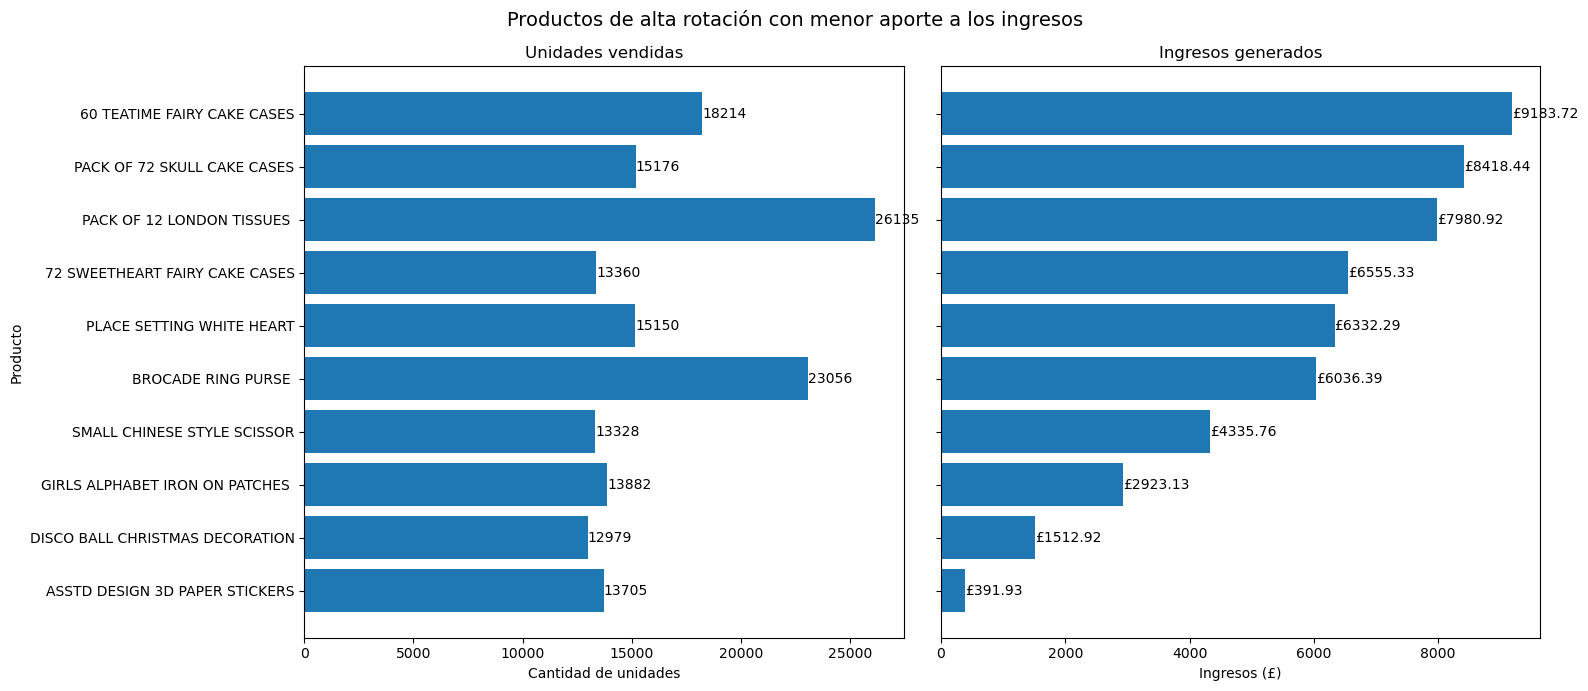

In [59]:
# Visualizamos los productos con alta rotación y bajo aporte a los ingresos
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Gráfico de cantidad
barras_quantity = axes[0].barh(
    top_10_final['Description'],
    top_10_final['Quantity']
)

axes[0].bar_label(barras_quantity, fmt='%d')
axes[0].set_title('Unidades vendidas')
axes[0].set_xlabel('Cantidad de unidades')
axes[0].set_ylabel('Producto')

# Gráfico de ingresos
barras_revenue = axes[1].barh(
    top_10_final['Description'],
    top_10_final['Revenue']
)

axes[1].bar_label(barras_revenue, fmt='£%.2f')
axes[1].set_title('Ingresos generados')
axes[1].set_xlabel('Ingresos (£)')

# Invertimos el eje para que el mayor volumen quede arriba
axes[0].invert_yaxis()

fig.suptitle(
    'Productos de alta rotación con menor aporte a los ingresos',
    fontsize=14
)

plt.tight_layout()
plt.show()

### Conclusión: 
Los resultados muestran que una alta rotación no necesariamente implica un alto aporte a los ingresos. Algunos productos registran un elevado volumen de unidades vendidas, pero generan ingresos relativamente bajos. Estos productos podrían representar una oportunidad para desarrollar estrategias de venta conjunta, por ejemplo, mediante paquetes o promociones que los combinen con productos de mayor valor o con menor rotación, buscando aprovechar su alta demanda para impulsar la venta de otros artículos.

Este análisis integra los resultados obtenidos en las preguntas anteriores para explorar posibles oportunidades de venta cruzada. Se revisan las relaciones entre productos de alta rotación y bajo aporte a los ingresos, y los productos que suelen comprarse conjuntamente.

# 5. Pregunta de Investigación 5
¿Los países con más compras son necesariamente los que generan más ingresos?

In [60]:
## Agrupamos ventas por país e indicamos los invoiceNo unicos 
ventas_by_country = data_clean.groupby('Country')['InvoiceNo'].nunique()

In [61]:
ventas_by_country

Country
Australia                  69
Austria                    19
Bahrain                     4
Belgium                   119
Brazil                      1
Canada                      6
Channel Islands            33
Cyprus                     20
Czech Republic              5
Denmark                    21
EIRE                      360
European Community          5
Finland                    48
France                    461
Germany                   603
Greece                      6
Hong Kong                  15
Iceland                     7
Israel                      9
Italy                      55
Japan                      28
Lebanon                     1
Lithuania                   4
Malta                      10
Netherlands               101
Norway                     40
Poland                     24
Portugal                   71
RSA                         1
Saudi Arabia                2
Singapore                  10
Spain                     105
Sweden                     46
Sw

In [62]:
## Buscamos la cantidad de productos vendidos por país 
quantity_by_country = data_clean.groupby('Country')['Quantity'].sum()

In [63]:
quantity_by_country

Country
Australia                 83653
Austria                    4827
Bahrain                     260
Belgium                   23152
Brazil                      356
Canada                     2763
Channel Islands            9479
Cyprus                     6317
Czech Republic              592
Denmark                    8188
EIRE                     142613
European Community          497
Finland                   10666
France                   110480
Germany                  117448
Greece                     1556
Hong Kong                  4769
Iceland                    2458
Israel                     4353
Italy                      7999
Japan                     25218
Lebanon                     386
Lithuania                   652
Malta                       944
Netherlands              200128
Norway                    19247
Poland                     3653
Portugal                  16180
RSA                         352
Saudi Arabia                 75
Singapore                  5234


In [64]:
## buscamos la cantidad de ingresos por país 
revenue_by_country = data_clean.groupby('Country')['Revenue'].sum()

In [65]:
revenue_by_country

Country
Australia                137077.270
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20086.290
Cyprus                    12946.290
Czech Republic              707.720
Denmark                   18768.140
EIRE                     263276.820
European Community         1291.750
Finland                   22326.740
France                   197403.900
Germany                  221698.210
Greece                     4710.520
Hong Kong                 10117.040
Iceland                    4310.000
Israel                     7907.820
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              284661.540
Norway                    35163.460
Poland                     7213.140
Portugal            

In [66]:
## Unimos las 3 métricas como columnas
country_summary = pd.concat(
    [ventas_by_country, quantity_by_country, revenue_by_country],
    axis=1
)

In [67]:
## Cambiamos InvoiceNo por Purchases 
country_summary.columns = ['Purchases', 'Quantity', 'Revenue']

In [68]:
country_summary 

,Purchases,Quantity,Revenue
Country,,,
Australia,69,83653,137077.270
Austria,19,4827,10154.320
Bahrain,4,260,548.400
Belgium,119,23152,40910.960
Brazil,1,356,1143.600
Canada,6,2763,3666.380
Channel Islands,33,9479,20086.290
Cyprus,20,6317,12946.290
Czech Republic,5,592,707.720


In [69]:
## Eliminamos los registros Unspecified porque no son útiles en nuestra pregunta de analísis 
country_summary_q5 = country_summary.drop('Unspecified')

In [70]:
country_summary_q5['Revenue_per_Purchase'] = country_summary_q5['Revenue'] / country_summary_q5['Purchases']

In [71]:
country_summary_q5.head()

,Purchases,Quantity,Revenue,Revenue_per_Purchase
Country,,,,
Australia,69,83653,137077.27,1986.627101
Austria,19,4827,10154.32,534.437895
Bahrain,4,260,548.40,137.100000
Belgium,119,23152,40910.96,343.789580
Brazil,1,356,1143.60,1143.600000


**Filtramos las compras para evitar que países con muy pocas compras distorsionen la comparación, analizaremos países con al menos 10 compras**

In [72]:
country_summary_q5_filtered = country_summary_q5[country_summary_q5['Purchases'] >= 10]

In [73]:
country_summary_q5_filtered.shape

(23, 4)

In [74]:
country_summary_q5_filtered.index

Index(['Australia', 'Austria', 'Belgium', 'Channel Islands', 'Cyprus',
       'Denmark', 'EIRE', 'Finland', 'France', 'Germany', 'Hong Kong', 'Italy',
       'Japan', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal',
       'Singapore', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom'],
      dtype='object', name='Country')

In [75]:
country_summary_q5.sort_values('Purchases', ascending=False).head(5)

,Purchases,Quantity,Revenue,Revenue_per_Purchase
Country,,,,
United Kingdom,21396,4412091,8187806.364,382.679303
Germany,603,117448,221698.210,367.658723
France,461,110480,197403.900,428.208026
EIRE,360,142613,263276.820,731.324500
Belgium,119,23152,40910.960,343.789580


**Ajuste de la visualización**

Reino Unido tiene una cantidad de compras e ingresos muy superior a la de los demás países. Al incluirlo en la misma escala, los otros países quedan agrupados y sus diferencias son difíciles de apreciar. Por eso, el primer gráfico muestra todos los países y el segundo excluye Reino Unido y utiliza una escala logarítmica para facilitar la comparación entre los demás mercados.

In [76]:
sin_uk= country_summary_q5_filtered[
country_summary_q5_filtered.index != 'United Kingdom'
]

In [77]:
con_uk = country_summary_q5_filtered[
    country_summary_q5_filtered.index == "United Kingdom"
]

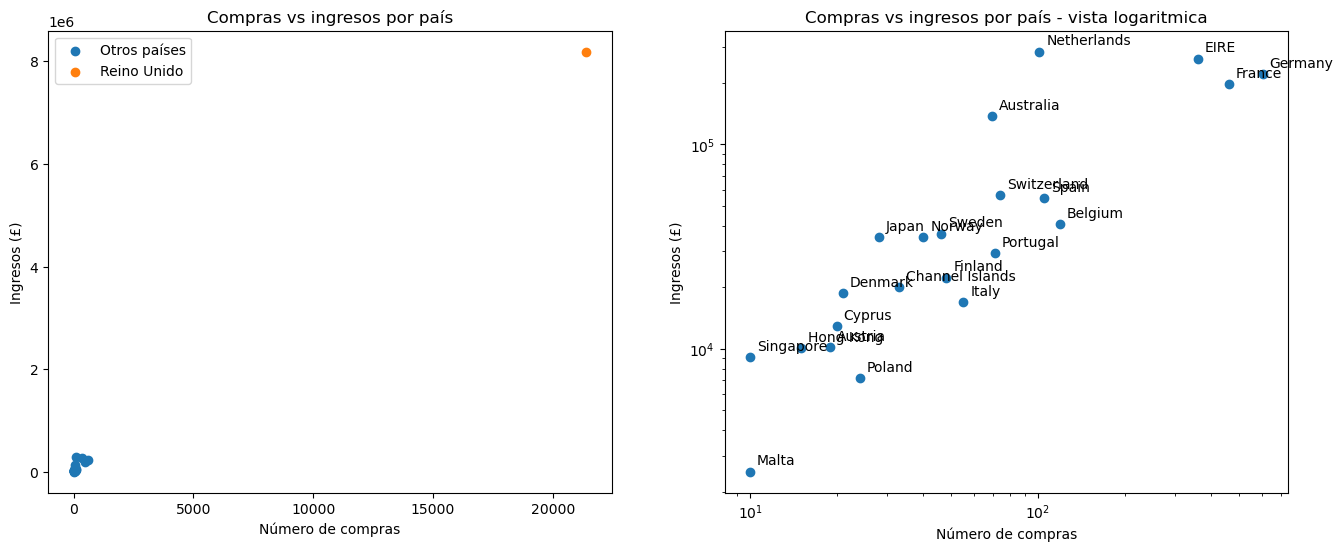

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    sin_uk['Purchases'],
    sin_uk['Revenue'],
    label="Otros países"
)

axes[0].scatter(
    con_uk['Purchases'],
    con_uk['Revenue'],
    label="Reino Unido"
)

axes[0].set_title("Compras vs ingresos por país")
axes[0].set_xlabel("Número de compras")
axes[0].set_ylabel("Ingresos (£)")
axes[0].legend()

axes[1].scatter(

   sin_uk['Purchases'], 
    sin_uk['Revenue']
)

axes[1].set_title("Compras vs ingresos por país - vista logaritmica") 
axes[1].set_xlabel("Número de compras")
axes[1].set_ylabel("Ingresos (£)")

plt.xscale('log')
plt.yscale('log')

for pais in sin_uk.index:
    plt.annotate(
    pais,
    (sin_uk.loc[pais, 'Purchases'],
     sin_uk.loc[pais, 'Revenue']),
    xytext=(5, 5),
    textcoords='offset points'
)


### Conclusiones: 
El Reino Unido concentra el mayor número de compras y los mayores ingresos del conjunto analizado. Sin embargo, esta relación no es proporcional en todos los mercados; por ejemplo, Países Bajos registra menos compras que Alemania y Francia, pero mayores ingresos por compra. Esta información puede ayudar a la empresa a segmentar sus mercados y diseñar estrategias como ventas cruzadas, paquetes o promociones según el comportamiento de cada país.



# 6. PREGUNTA DE INVESTIGACIÓN 6 
¿Existen patrones estacionales en la demanda de determinados productos?



In [79]:
# Calculamos la demanda mensual de cada producto
demanda_mensual = data_clean.groupby(['StockCode', 'Mes'])['Quantity'].sum()

In [80]:
demanda_mensual

StockCode     Mes    
10002         2010-12    251
              2011-01    340
              2011-02     52
              2011-03     28
              2011-04    189
                        ... 
gift_0001_40  2011-07      1
gift_0001_50  2010-12      1
              2011-05      1
              2011-06      2
m             2010-12      1
Name: Quantity, Length: 34242, dtype: int64

In [81]:
# Restablecemos el índice para convertir StockCode y Mes en columnas
demanda_mensual = demanda_mensual.reset_index()

In [82]:
# Filtramos los registros que no son útiles para el análisis de demanda
demanda_mensual = demanda_mensual[
    (demanda_mensual['Quantity'] > 0) &
    (demanda_mensual['StockCode'].notna()) &
    (~demanda_mensual['StockCode'].isin(['DOT', 'POST', 'PADS', 'M', 'm', 'S'])) &
    (~demanda_mensual['StockCode'].str.startswith('gift_', na=False))
]

In [83]:
## Calculamos la cantidad total de unidades vendidas por mes
demanda_por_mes = demanda_mensual.groupby('Mes')['Quantity'].sum()

In [84]:
demanda_por_mes

Mes
2010-12    350058
2011-01    308135
2011-02    281133
2011-03    372941
2011-04    296364
2011-05    391479
2011-06    381720
2011-07    396170
2011-08    411318
2011-09    563197
2011-10    598145
2011-11    750740
2011-12    230291
Name: Quantity, dtype: int64

In [85]:
## Creamos una tabla con la descripción de cada producto
descripcion_productos = data_clean[
    ['StockCode', 'Description']
].drop_duplicates('StockCode')

In [86]:
descripcion_productos

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.
...,...,...
506971,85179a,GREEN BITTY LIGHT CHAIN
510187,23617,SET 10 CARDS SWIRLY XMAS TREE 17104
524618,90214U,"LETTER ""U"" BLING KEY RING"
534753,47591b,SCOTTIES CHILDRENS APRON


In [87]:
## Unimos la demanda mensual con la descripción de cada producto
demanda_mensual = demanda_mensual.merge(
    descripcion_productos,
    on='StockCode'
)

In [88]:
demanda_mensual

,StockCode,Mes,Quantity,Description
0,10002,2010-12,251,INFLATABLE POLITICAL GLOBE
1,10002,2011-01,340,INFLATABLE POLITICAL GLOBE
2,10002,2011-02,52,INFLATABLE POLITICAL GLOBE
3,10002,2011-03,28,INFLATABLE POLITICAL GLOBE
4,10002,2011-04,189,INFLATABLE POLITICAL GLOBE
...,...,...,...,...
33787,DCGSSGIRL,2011-05,4,GIRLS PARTY BAG
33788,DCGSSGIRL,2011-07,5,GIRLS PARTY BAG
33789,DCGSSGIRL,2011-08,6,GIRLS PARTY BAG
33790,DCGSSGIRL,2011-10,1,GIRLS PARTY BAG


In [89]:
demanda_mensual[['StockCode', 'Description']].drop_duplicates().head(20)

,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
5,10080,GROOVY CACTUS INFLATABLE
12,10120,DOGGY RUBBER
22,10123C,HEARTS WRAPPING TAPE
24,10124A,SPOTS ON RED BOOKCOVER TAPE
28,10124G,ARMY CAMO BOOKCOVER TAPE
32,10125,MINI FUNKY DESIGN TAPES
44,10133,COLOURING PENCILS BROWN TUBE
54,10135,COLOURING PENCILS BROWN TUBE
67,11001,ASSTD DESIGN RACING CAR PEN


In [90]:
demanda_mensual[ 
demanda_mensual['StockCode'] == '10002'
]

,StockCode,Mes,Quantity,Description
0,10002,2010-12,251,INFLATABLE POLITICAL GLOBE
1,10002,2011-01,340,INFLATABLE POLITICAL GLOBE
2,10002,2011-02,52,INFLATABLE POLITICAL GLOBE
3,10002,2011-03,28,INFLATABLE POLITICAL GLOBE
4,10002,2011-04,189,INFLATABLE POLITICAL GLOBE


In [91]:
demanda_mensual[ 
demanda_mensual['StockCode'] == '10002'
][['Mes', 'Quantity', 'StockCode']]

,Mes,Quantity,StockCode
0,2010-12,251,10002
1,2011-01,340,10002
2,2011-02,52,10002
3,2011-03,28,10002
4,2011-04,189,10002


In [92]:
producto_10002 = demanda_mensual[
    demanda_mensual['StockCode'] == '10002'
]

In [93]:
producto_10002

,StockCode,Mes,Quantity,Description
0,10002,2010-12,251,INFLATABLE POLITICAL GLOBE
1,10002,2011-01,340,INFLATABLE POLITICAL GLOBE
2,10002,2011-02,52,INFLATABLE POLITICAL GLOBE
3,10002,2011-03,28,INFLATABLE POLITICAL GLOBE
4,10002,2011-04,189,INFLATABLE POLITICAL GLOBE


In [94]:
## Exploramos un segundo producto

producto_15034 = demanda_mensual[ 
demanda_mensual['StockCode'] == '15034'
]

In [95]:
producto_15034

,StockCode,Mes,Quantity,Description
88,15034,2010-12,45,PAPER POCKET TRAVELING FAN
89,15034,2011-01,177,PAPER POCKET TRAVELING FAN
90,15034,2011-02,80,PAPER POCKET TRAVELING FAN
91,15034,2011-03,123,PAPER POCKET TRAVELING FAN
92,15034,2011-04,541,PAPER POCKET TRAVELING FAN
93,15034,2011-05,827,PAPER POCKET TRAVELING FAN
94,15034,2011-06,1621,PAPER POCKET TRAVELING FAN
95,15034,2011-07,212,PAPER POCKET TRAVELING FAN
96,15034,2011-08,164,PAPER POCKET TRAVELING FAN
97,15034,2011-09,250,PAPER POCKET TRAVELING FAN


In [96]:
## Exploramos un tercer producto 

producto_15044A = demanda_mensual[
demanda_mensual['StockCode'] == '15044A'
]

In [97]:
producto_15044A

,StockCode,Mes,Quantity,Description
127,15044A,2010-12,6,PINK PAPER PARASOL
128,15044A,2011-01,20,PINK PAPER PARASOL
129,15044A,2011-02,13,PINK PAPER PARASOL
130,15044A,2011-03,95,PINK PAPER PARASOL
131,15044A,2011-04,42,PINK PAPER PARASOL
132,15044A,2011-05,72,PINK PAPER PARASOL
133,15044A,2011-06,63,PINK PAPER PARASOL
134,15044A,2011-07,53,PINK PAPER PARASOL
135,15044A,2011-08,27,PINK PAPER PARASOL
136,15044A,2011-09,32,PINK PAPER PARASOL


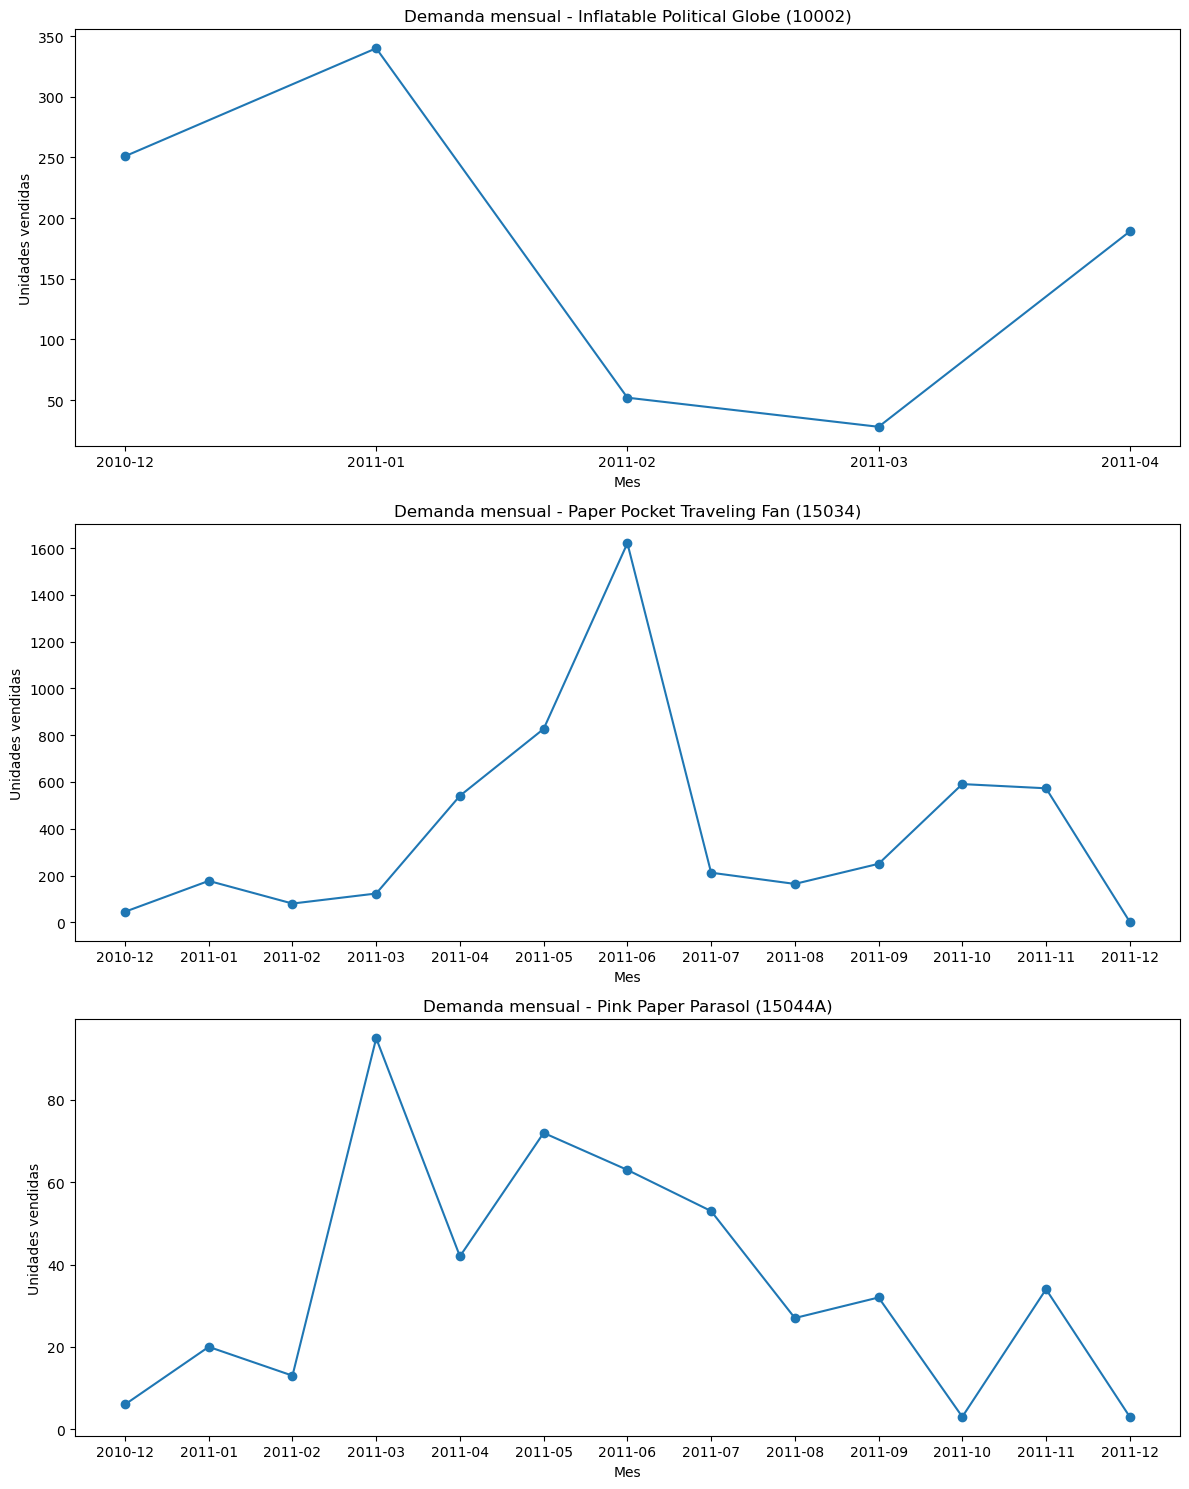

In [98]:
## Graficamos los 3 productos juntos

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Producto 10002
axes[0].plot(
    producto_10002['Mes'],
    producto_10002['Quantity'],
    marker='o'
)
axes[0].set_title('Demanda mensual - Inflatable Political Globe (10002)')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Unidades vendidas')


# Producto 15034
axes[1].plot(
    producto_15034['Mes'],
    producto_15034['Quantity'],
    marker='o'
)
axes[1].set_title('Demanda mensual - Paper Pocket Traveling Fan (15034)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Unidades vendidas')


# Producto 15044A
axes[2].plot(
    producto_15044A['Mes'],
    producto_15044A['Quantity'],
    marker='o'
)
axes[2].set_title('Demanda mensual - Pink Paper Parasol (15044A)')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Unidades vendidas')


plt.tight_layout()
plt.show()

In [99]:
producto_10002[['Mes', 'Quantity']]

,Mes,Quantity
0,2010-12,251
1,2011-01,340
2,2011-02,52
3,2011-03,28
4,2011-04,189


### Conclusiones: 

Se observan variaciones importantes en la demanda mensual de los productos analizados. Un comportamiento interesante es que los tres productos presentan un incremento de la demanda entre diciembre de 2010 y enero de 2011. Por ejemplo, el producto 15034 presenta posteriormente un incremento considerable, alcanzando su mayor volumen en junio, mientras que el producto 15044A presenta fluctuaciones a lo largo del año. También se identificaron productos con registros disponibles únicamente durante determinados meses, como el 10002. Sin embargo, debido a que el conjunto de datos comprende aproximadamente un año de información, no es posible confirmar que estos comportamientos correspondan a patrones estacionales recurrentes. No obstante, los resultados permiten identificar períodos de mayor y menor demanda dentro del período analizado, que podrían utilizarse como punto de partida para análisis posteriores de inventario y planificación de ventas.

# Conclusiones generales

El análisis permitió obtener una visión más completa del comportamiento de las ventas, identificando diferencias relevantes entre productos, períodos y mercados. Analizar estas diferencias permite comprender mejor dónde se generan los ingresos y detectar oportunidades comerciales.

Esta información puede utilizarse para apoyar decisiones sobre inventario, planificación de ventas y estrategias comerciales, aprovechando los patrones identificados en los productos, las compras y los distintos mercados.